In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
cafe.settings.backend = "python_function"

[07/23/2025 11:29:17] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

Data

In [2]:
import pandas as pd
import scanpy as sc

# creating from Anndata
adata = sc.read_h5ad(f"../../tests/data/bifurcating.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["counts"] = fadata.X.copy()
fadata.layers["expression"] = fadata.X.copy()

cluster_key = "lineage"
fadata.obs.index = fadata.obs["cell_id"].tolist()

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             


AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'counts', 'expression'

Method

In [3]:
method = cafe.method.FateMethod(method_name="paga")
method.get_parameter_df() # show parameter dataframe

                      DEBUG    FunctionBackend __init__                                                                                                                                                 
                      INFO     Loaded function: <function cf_paga at 0x7ca1beaa6200> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py                     
                      INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at 0x7ca1bf726020>                                                                              


,description,type,default,update,distribution
id,,,,,
cluster_key,Key in the data frame that contains the cluste...,character,clusters,NaN,NaN
repreprocess,"whether reprocess the anndata object, includin...",boolean,True,NaN,NaN
filter_and_normalize_kwargs,"Parameters for preprocess in scvelo style, ref...",dict,"{'min_shared_counts': 20, 'n_top_genes': 2000}",True,NaN
neighbors_kwargs,Parameters for neighbor construction in scanpy...,dict,"{'n_pcs': 20, 'n_neighbors': 30}",True,NaN
n_dcs,Number of diffusion components for denoising g...,integer,15,NaN,"{'type': 'uniform', 'lower': 0, 'upper': 40}"
connectivity_cutoff,Cutoff for the connectivity matrix,numeric,0.5,NaN,"{'type': 'uniform', 'lower': 0, 'upper': 1}"


In [4]:
# PAGA need more prior information and parameters
prior_information = {"start_id": "cell1"}
parameters = {"cluster_key": "lineage", "connectivity_cutoff": 0.5}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
method.infer_trajectory(fadata, parameters=parameters)  # add parameters when inferring trajectory

Filtered out 42 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.
[07/23/2025 11:29:20] DEBUG    Add trajectory by wrapper type: branch                                                                                                                                   
                      DEBUG    Wrapper type: branch                                                                                                                                                     
                      DEBUG    FateAnnData add_trajectory_branch                                                                                                                                        
                      DEBUG    FateAnnData add_trajectory                                                                                                                                     

Plot

                      DEBUG    plot_trajectory                                                                                                                                                          
[07/23/2025 11:29:22] DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (208, 1000), finished!                                                                                                                            


<Axes: title={'center': 'milestone'}, xlabel='UMAP1', ylabel='UMAP2'>

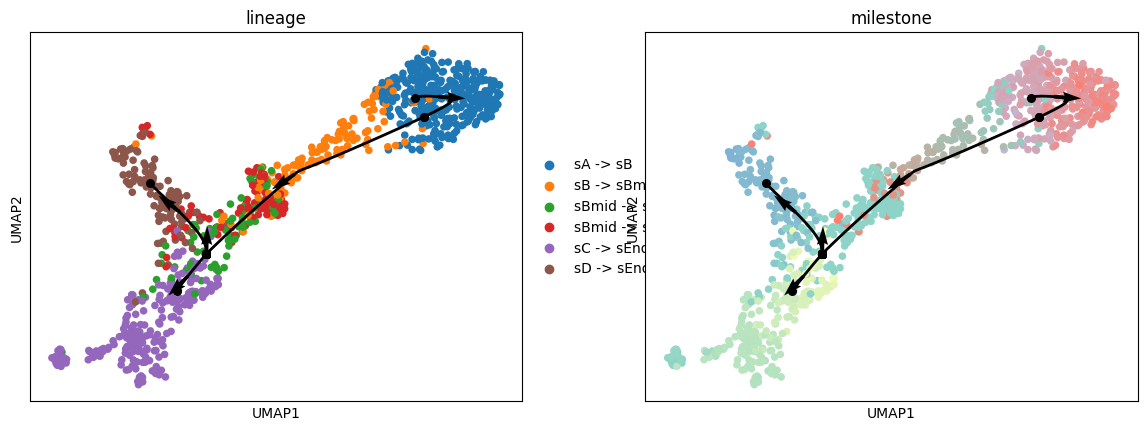

In [5]:
cafe.plot.plot_trajectory(fadata, basis="umap", color=["lineage", "milestone"])

Save

In [6]:
fadata.write_h5ad("output.h5ad")

[07/23/2025 11:29:25] DEBUG    transfer milestone color from tuple to list                                                                                                                              
                      DEBUG    transfer trajectory history: '20250723_112917__paga-python_function__VfQR8jCIvh' to dict                                                                                 
